<a href="https://colab.research.google.com/github/affanmohd65/affanmohd65/blob/main/Time_SeriesAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import yfinance as yf
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

stock_data=yf.download('NVDA', start='2026-01-01')
stock_data.head(10)

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA
Date,,,,,
2026-01-02,188.619949,192.694966,188.030656,189.608734,148240500
2026-01-05,187.890839,193.394136,185.923237,191.526404,183529700
2026-01-06,187.011917,191.935904,186.592431,190.287920,176862600
2026-01-07,188.879623,191.136865,186.332727,188.340288,153543200
2026-01-08,184.814590,189.319106,183.486224,188.879640,172457000
2026-01-09,184.634796,186.112989,183.446243,184.854529,131327500
2026-01-12,184.714706,186.892043,182.797047,182.996801,137968500
2026-01-13,185.583649,187.880850,183.176581,184.774638,160128900


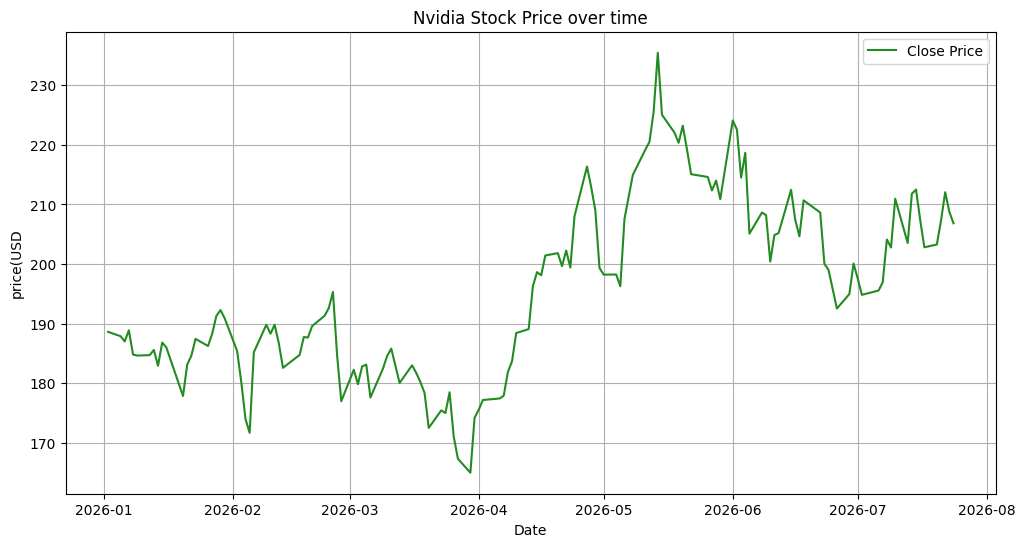

In [2]:
plt.figure(figsize=(12,6))
plt.plot(stock_data.index, stock_data['Close'],label='Close Price', color='#228b22')
plt.title('Nvidia Stock Price over time')
plt.xlabel('Date')
plt.ylabel('price(USD')
plt.legend()
plt.grid(True)
plt.show()

In [3]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition_additive=seasonal_decompose(stock_data['Close'],model='additive', period=30)

In [4]:
trend_additive=decomposition_additive.trend
seasonal_additive=decomposition_additive.seasonal
residual_additive=decomposition_additive.resid

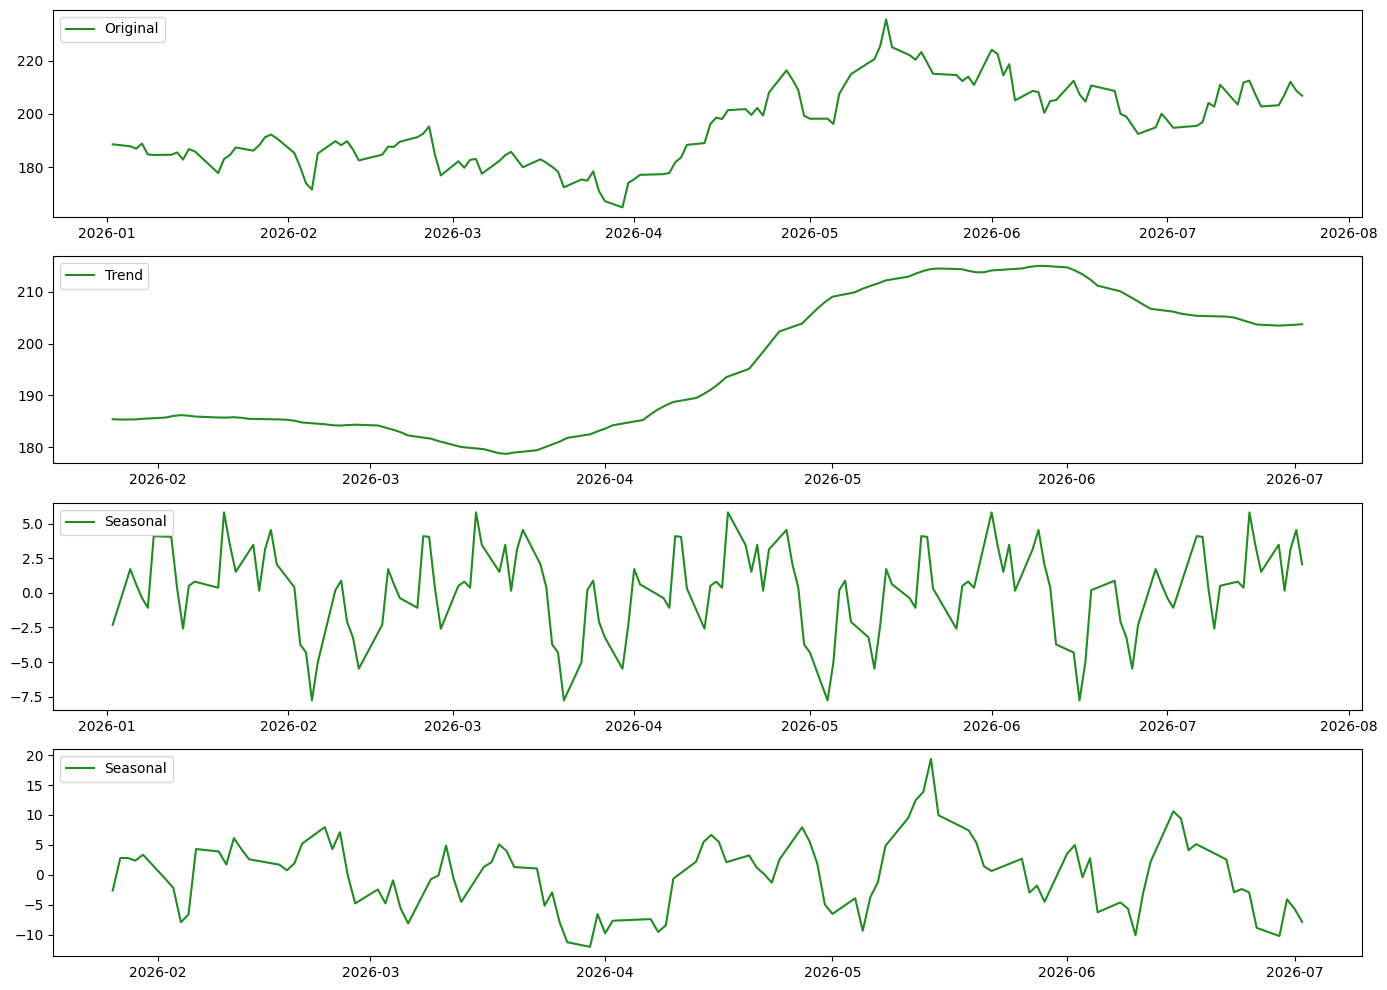

In [5]:
plt.figure(figsize=(14,10))
plt.subplot(411)

plt.plot(stock_data['Close'], label='Original',color='#228b22')
plt.legend(loc='upper left')
plt.subplot(412)

plt.plot(trend_additive, label='Trend', color='#228b22')
plt.legend(loc='upper left')
plt.subplot(413)

plt.plot(seasonal_additive, label='Seasonal',color='#228b22')
plt.legend(loc='upper left')
plt.subplot(414)

plt.plot(residual_additive, label='Seasonal',color='#228b22')
plt.legend(loc='upper left')
plt.tight_layout()

plt.show()

# **STL Decomposition**

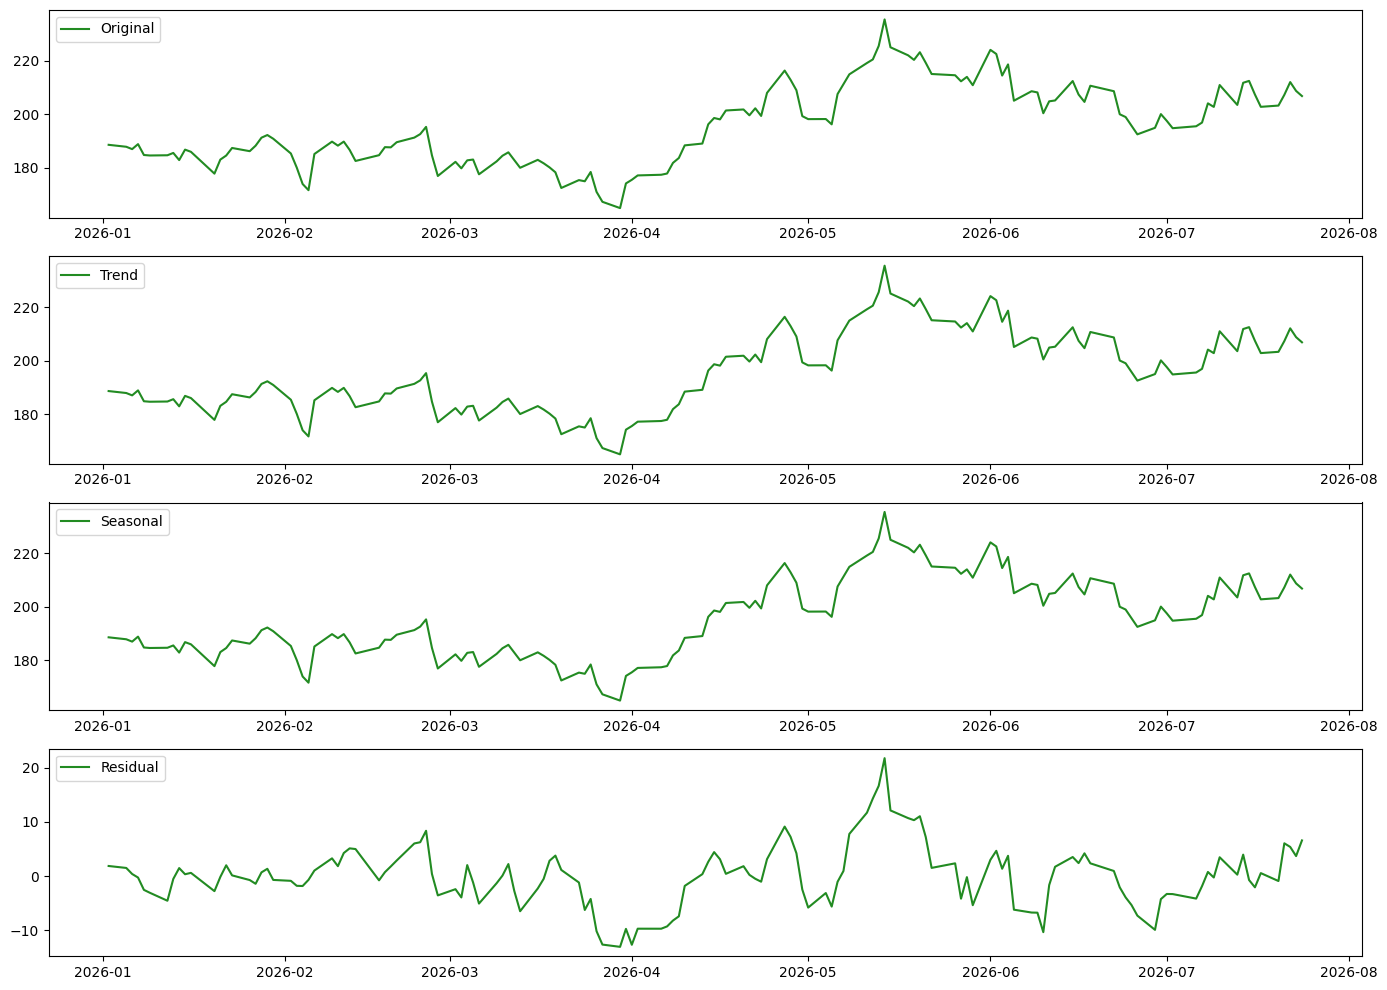

In [6]:
from statsmodels.tsa.seasonal import STL

#stl decomposition
stl=STL(stock_data['Close'],period=30)
result=stl.fit()

##plotting
plt.figure(figsize=(14,10))
plt.subplot(411)

plt.plot(result.observed, label='Original', color='#228b22')
plt.legend(loc='upper left')
plt.subplot(412)

plt.plot(result.observed, label='Trend', color='#228b22')
plt.legend(loc='upper left')
plt.subplot(413)

plt.plot(result.observed, label='Seasonal', color='#228b22')
plt.legend(loc='upper left')
plt.subplot(414)

plt.plot(result.resid, label='Residual', color='#228b22')
plt.legend(loc='upper left')
plt.tight_layout()

plt.show()

# **Stationarity Test**

In [7]:
from statsmodels.tsa.stattools import adfuller

#perform Augmented Dickey-Fuller test
adf_test=adfuller(stock_data['Close'])

print('ADF Test results: ')
print(f'ADF Statistic: {round(adf_test[0],3)}')
print(f'p-value: {round(adf_test[1],3)}')
print('Critical Values:')
for key, value in adf_test[4].items():
  print(f' {key}:{round(value,3)}')

ADF Test results: 
ADF Statistic: -1.851
p-value: 0.356
Critical Values:
 1%:-3.478
 5%:-2.883
 10%:-2.578


In [8]:
from statsmodels.tsa.stattools import kpss

#perform KPSS test
kpss_test=kpss(stock_data['Close'], regression='ct')

print('KPSS Test results: ')
print(f'KPSS Statistic: {round(kpss_test[0],2)}')
print(f'p-value: {kpss_test[1]}')
print('Critical Values:')
for key, value in kpss_test[3].items():
  print(f' {key}:{value,3}')

KPSS Test results: 
KPSS Statistic: 0.18
p-value: 0.022299284692655567
Critical Values:
 10%:(0.119, 3)
 5%:(0.146, 3)
 2.5%:(0.176, 3)
 1%:(0.216, 3)


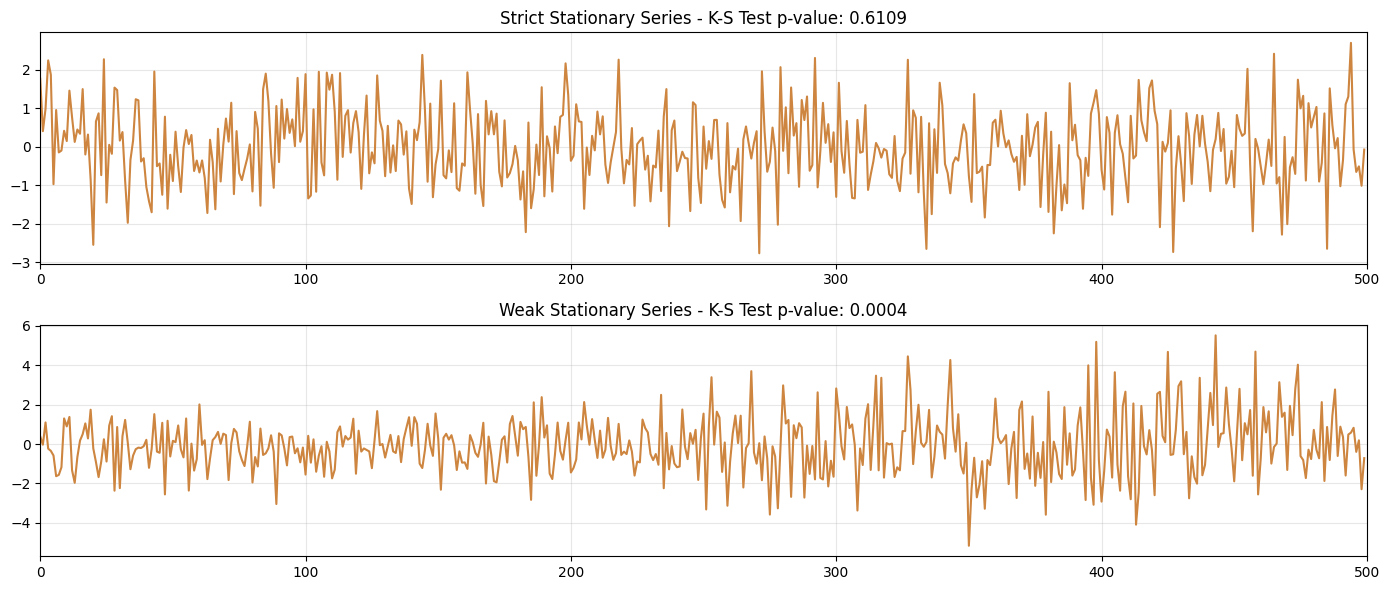

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

np.random.seed(0)
n=500

# Strictly stationarity series: normally distributed random noise
strict_stationarity_series=np.random.normal(0,1,n)

# Non-strictly series: chnaging variance
non_strict_stationarity_series=np.concatenate([
    np.random.normal(0,1,n//2),
    np.random.normal(0,2,n//2)
])

# Function to split the series into two halves and perform K-S test
def ks_test(series):
    split=len(series) // 2
    series_first_half=series[:split]
    series_second_half=series[split:]
    stat,p_value=ks_2samp(series_first_half, series_second_half)
    return stat, p_value

# Perform the K-S test on strictly series
ks_stat_strict, ks_pvalue_strict=ks_test(strict_stationarity_series)

# perform the K-S test on non strictly series
ks_stat_non_strict, ks_pvalue_non_strict=ks_test(non_strict_stationarity_series)

# Plotting
plt.figure(figsize=(14,6))
# Plot Strictly Stationary Series
plt.subplot(2, 1, 1)
plt.plot(strict_stationarity_series, color='peru')
plt.title(f"Strict Stationary Series - K-S Test p-value: {ks_pvalue_strict:.4f}")
plt.xlim(0, n)
plt.grid(alpha=0.3)

# Plot Non-Strictly Stationary Series
plt.subplot(2, 1, 2)
plt.plot(non_strict_stationarity_series, color='peru')
plt.title(f"Weak Stationary Series - K-S Test p-value: {ks_pvalue_non_strict:.4f}")
plt.xlim(0, n)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# **Making Data Staionary**

In [10]:
## performing ADF and KPSS tests
def adf_test(series):
  result = adfuller(series)
  print('ADF Statistic:',result[0])
  print('p-value:', result[1])
  for key,value in result[4].items():
    print('Critical Value (%s): %.3f' % (key, value))

def kpss_test(series):
  result = kpss(series, regression='c')
  print('KPSS Statistic:',result[0])
  print('p-value:', result[1])
  for key,value in result[3].items():
    print('Critical Value (%s): %.3f' % (key, value))

In [11]:
prices=stock_data['Close']

In [12]:
adf_test(prices)

ADF Statistic: -1.8505295019380645
p-value: 0.35567914491102187
Critical Value (1%): -3.478
Critical Value (5%): -2.883
Critical Value (10%): -2.578


In [13]:
prices_diff = prices.diff().dropna()

In [14]:
adf_test(prices_diff)

ADF Statistic: -12.197449968874627
p-value: 1.2451548398163042e-22
Critical Value (1%): -3.479
Critical Value (5%): -2.883
Critical Value (10%): -2.578


In [15]:
prices = stock_data['Close'].squeeze()

print(type(prices))
print(prices.shape)

<class 'pandas.core.series.Series'>
(140,)


# **Transformation**

In [16]:
import numpy as np
from scipy import stats

## Log Transformation
prices_log=np.log(prices)

## sqrt transformation
prices_sqrt = np.sqrt(prices)

##Box-Cox (requires all positive values)
prices_boxcox,lam=stats.boxcox(prices[prices>0])

In [17]:
prices_log

,NVDA
Date,
2026-01-02,5.239734
2026-01-05,5.235861
2026-01-06,5.231172
2026-01-07,5.241110
2026-01-08,5.219353
...,...
2026-07-20,5.314584
2026-07-21,5.334119
2026-07-22,5.356869


In [18]:
prices_sqrt

,NVDA
Date,
2026-01-02,13.733898
2026-01-05,13.707328
2026-01-06,13.675230
2026-01-07,13.743348
2026-01-08,13.594653
...,...
2026-07-20,14.257629
2026-07-21,14.397569
2026-07-22,14.562280


In [19]:
prices_boxcox

array([0.95681197, 0.95679534, 0.95677512, 0.95681786, 0.95672371,
       0.95671945, 0.95672135, 0.95674185, 0.9566783 , 0.95677073,
       0.95675167, 0.95655229, 0.95668265, 0.95671898, 0.95678503,
       0.95675727, 0.95680447, 0.95687168, 0.95689339, 0.95686306,
       0.95673715, 0.9566096 , 0.95645079, 0.95638814, 0.95673245,
       0.95683879, 0.95680492, 0.95683902, 0.95676818, 0.95667032,
       0.95672206, 0.95679214, 0.9567903 , 0.95683386, 0.95687234,
       0.95690079, 0.95695887, 0.95672016, 0.95652966, 0.9566623 ,
       0.95660236, 0.95667589, 0.95668313, 0.95654588, 0.95666644,
       0.95671732, 0.95674724, 0.95667854, 0.9566076 , 0.95668047,
       0.95664912, 0.95661134, 0.95656503, 0.95641083, 0.95648951,
       0.9564779 , 0.95656808, 0.95637073, 0.95626535, 0.95619628,
       0.95645665, 0.9564924 , 0.95653507, 0.95654151, 0.9565533 ,
       0.95665279, 0.95669706, 0.9568072 , 0.95682261, 0.95697906,
       0.95702783, 0.95701719, 0.95708438, 0.9570919 , 0.95704

In [20]:
adf_test(prices_boxcox)

ADF Statistic: -1.8326301375527327
p-value: 0.3643862483913759
Critical Value (1%): -3.478
Critical Value (5%): -2.883
Critical Value (10%): -2.578


In [21]:
## applying differencing
## THIS HELPS IN MAKING DATA STATIONARY

prices_log = np.log(prices)

prices_log_diff = prices_log.diff().dropna()

adf_test(prices_log_diff)

ADF Statistic: -12.045882210416144
p-value: 2.6657235761444686e-22
Critical Value (1%): -3.479
Critical Value (5%): -2.883
Critical Value (10%): -2.578


In [22]:
## using linear trend
from scipy import signal

trend=np.polyfit(np.arange(len(prices)),prices,1)
trendline=np.polyval(trend, np.arange(len(prices)))
prices_detrended=prices - trendline

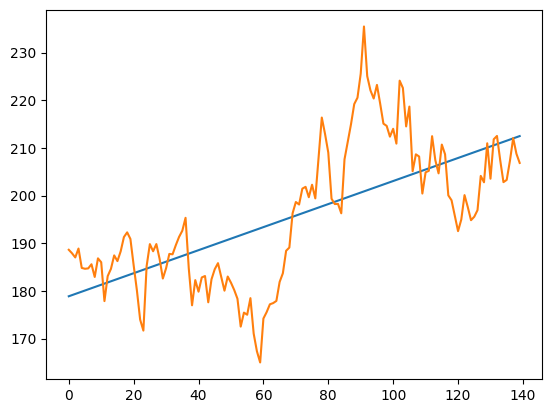

In [23]:
plt.plot(np.arange(len(prices)),trendline) ## Blue Line
plt.plot(np.arange(len(prices)), prices) ## Orange line

In [24]:
adf_test(prices_detrended)

## output shows p-value < 0.05, data is stationary(Reject the null hypothesis)

ADF Statistic: -2.620380855108137
p-value: 0.0888576935801838
Critical Value (1%): -3.478
Critical Value (5%): -2.883
Critical Value (10%): -2.578


In [25]:
## using a moving average to remove trend

window=12 ## defining window size
prices_ma=prices.rolling(window=window).mean()
prices_detrended=prices - prices_ma
prices_detrended=prices_detrended.dropna()

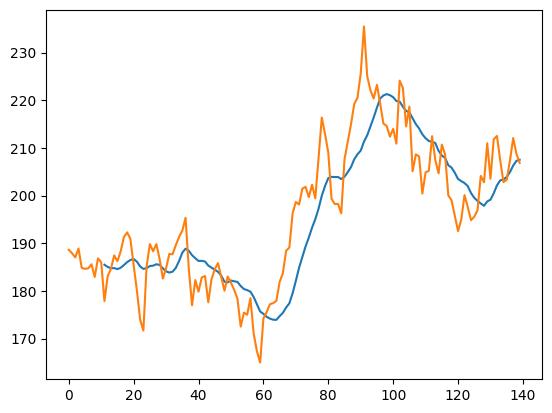

In [26]:
plt.plot(np.arange(len(prices)),prices_ma) ## Blue Line
plt.plot(np.arange(len(prices)), prices) ## Orange line

In [27]:
## Seasonal decomposition using moving averages

from statsmodels.tsa.seasonal import seasonal_decompose

decomposition=seasonal_decompose(prices,model='additive',period=30)
prices_adjusted=prices/decomposition.seasonal
prices_adjusted=prices_adjusted.dropna()

In [28]:
adf_test(prices_adjusted)

ADF Statistic: -5.132060845763364
p-value: 1.2080621299172936e-05
Critical Value (1%): -3.483
Critical Value (5%): -2.885
Critical Value (10%): -2.579


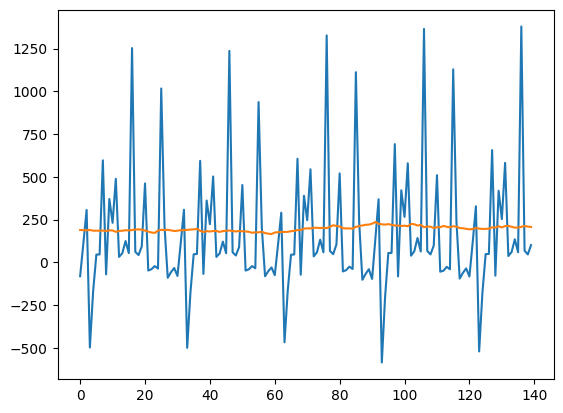

In [29]:
plt.plot(np.arange(len(prices)),prices_adjusted) ## Blue Line
plt.plot(np.arange(len(prices)), prices) ## Orange line

# **White Noise & Random Walk**

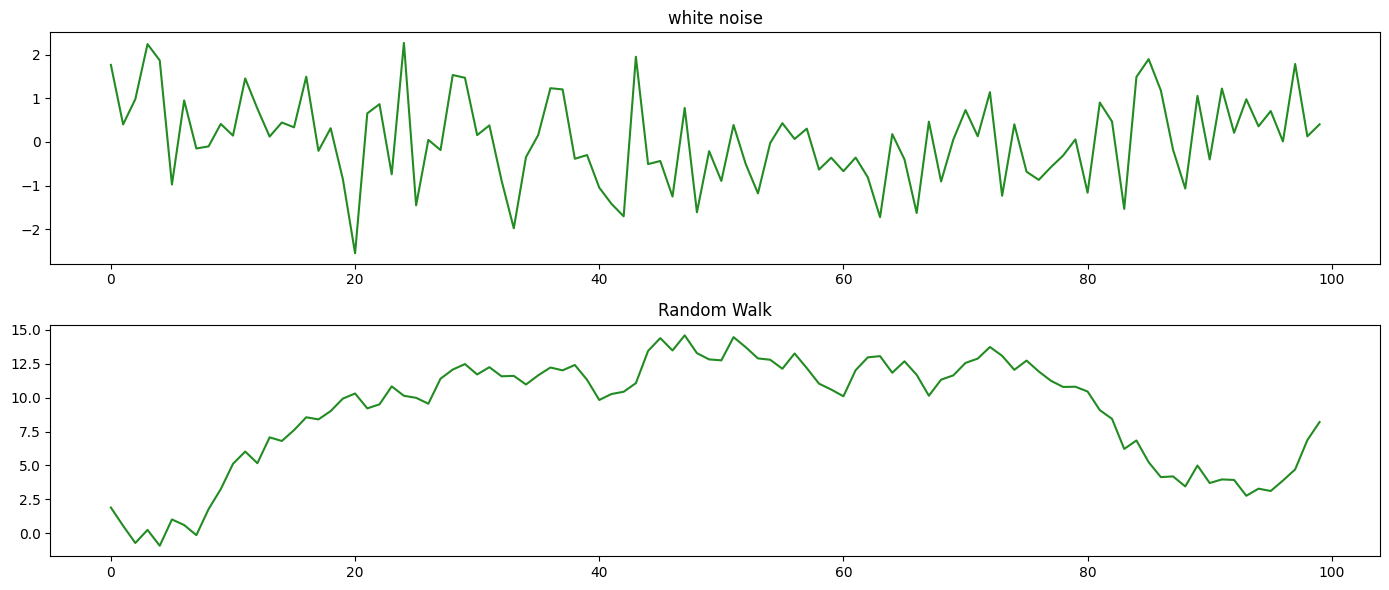


Ljung test for white noise:
      lb_stat  lb_pvalue
10  13.169306   0.214359

Ljung test for Random Walk:
       lb_stat      lb_pvalue
10  506.277458  2.010757e-102


In [30]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import acorr_ljungbox

## generating white noise and random walk for comparison
np.random.seed(0)
n=100

#white noise
white_noise=np.random.normal(0,1,n)

#random walk
random_shocks=np.random.normal(0,1,n)
random_walk=np.cumsum(random_shocks)

# plotting
plt.figure(figsize=(14,6))

plt.subplot(2,1,1)
plt.plot(white_noise, color='#228b22')
plt.title(f'white noise')

plt.subplot(2,1,2)
plt.plot(random_walk, color='#228b22')
plt.title(f'Random Walk')

plt.tight_layout()
plt.show()


# Ljung-test
print("\nLjung test for white noise:")
lb_test_white_noise=acorr_ljungbox(white_noise, lags=[10],return_df=True)
print(lb_test_white_noise)

print("\nLjung test for Random Walk:")
lb_test_random_walk=acorr_ljungbox(random_walk, lags=[10],return_df=True)
print(lb_test_random_walk)

# **Forecasting Models**

AR MODEL


In [31]:
## making stationary data
stock_data=yf.download('NVDA', start='2026-01-01')

nvidia_price_stationary=stock_data['Close'].diff().dropna()

## split into training and testing
train_data, test_data=nvidia_price_stationary[:-30], nvidia_price_stationary[-30:]

[*********************100%***********************]  1 of 1 completed


In [32]:
len(train_data)

109

In [33]:
len(test_data)

30

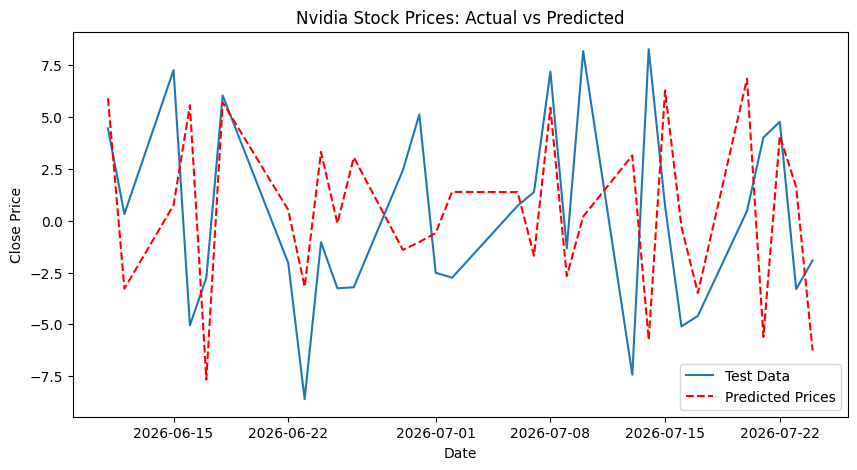

RMSE:  5.75


In [34]:
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_squared_error
import numpy as np
import warnings
warnings.filterwarnings('ignore')

#Fit Autoregressive model(AR) to training data
model=AutoReg(train_data, lags=30)
model_fit=model.fit()

# making predictions on test data
predictions=model_fit.predict(
    start=len(train_data),
    end=len(train_data) + len(test_data)-1,
    dynamic=False
)

## Plotting actual vs predicted values
plt.figure(figsize=(10,5))
plt.plot(test_data.index, test_data, label='Test Data')
plt.plot(test_data.index, predictions, color='red', linestyle='--', label='Predicted Prices')
plt.title('Nvidia Stock Prices: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

## evaluating model using RMSE score
rmse=round(np.sqrt(mean_squared_error(test_data, predictions)),2)
print('RMSE: ',rmse)


# **MA model**

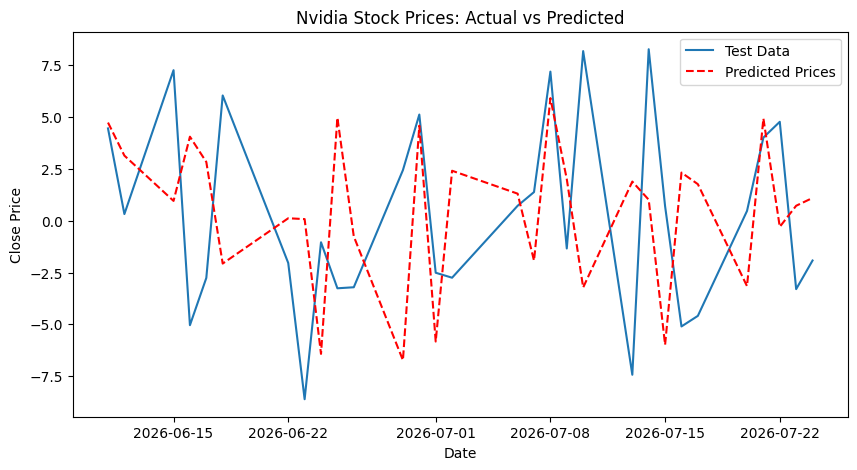

RMSE:  5.86


In [35]:
from statsmodels.tsa.arima.model import ARIMA

# Fit Moving Average(MA) model to training data
model=ARIMA(train_data, order=(0,0,30))
model_fit=model.fit()

#make predictions on test data
predictions=model_fit.predict(
    start=len(train_data),
    end=len(train_data) + len(test_data)-1,
    dynamic=False
)

## Plotting actual vs predicted values
plt.figure(figsize=(10,5))
plt.plot(test_data.index, test_data, label='Test Data')
plt.plot(test_data.index, predictions, color='red', linestyle='--', label='Predicted Prices')
plt.title('Nvidia Stock Prices: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

## evaluating model using RMSE score
rmse=round(np.sqrt(mean_squared_error(test_data, predictions)),2)
print('RMSE: ',rmse)

# **ARMA Model**

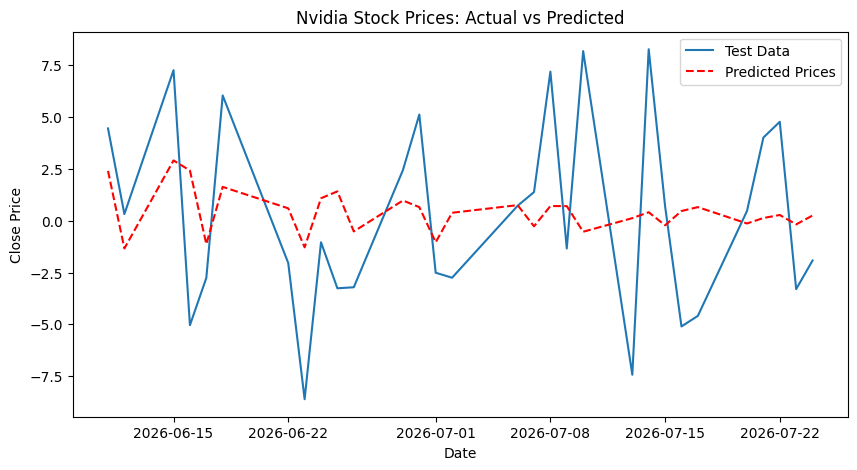

RMSE:  4.42


In [36]:
model=ARIMA(train_data, order=(7,0,7))
model_fit=model.fit()

#make predictions on test data
predictions=model_fit.predict(
    start=len(train_data),
    end=len(train_data) + len(test_data)-1,
    dynamic=False
)

## Plotting actual vs predicted values
plt.figure(figsize=(10,5))
plt.plot(test_data.index, test_data, label='Test Data')
plt.plot(test_data.index, predictions, color='red', linestyle='--', label='Predicted Prices')
plt.title('Nvidia Stock Prices: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

## evaluating model using RMSE score
rmse=round(np.sqrt(mean_squared_error(test_data, predictions)),2)
print('RMSE: ',rmse)

# **ARIMA Model**

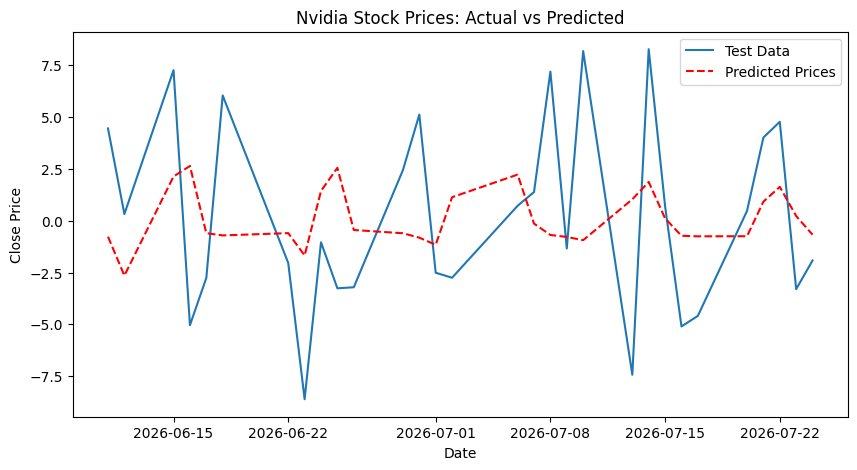

RMSE:  4.7


In [37]:
model=ARIMA(train_data, order=(7,1,7))
model_fit=model.fit()

#make predictions on test data
predictions=model_fit.predict(
    start=len(train_data),
    end=len(train_data) + len(test_data)-1,
    dynamic=False
)

## Plotting actual vs predicted values
plt.figure(figsize=(10,5))
plt.plot(test_data.index, test_data, label='Test Data')
plt.plot(test_data.index, predictions, color='red', linestyle='--', label='Predicted Prices')
plt.title('Nvidia Stock Prices: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

## evaluating model using RMSE score
rmse=round(np.sqrt(mean_squared_error(test_data, predictions)),2)
print('RMSE: ',rmse)

# **VECTOR MODEL**

In [38]:
tsla_data = yf.download('TSLA', start='2026-01-01')

stock_data = yf.download('NVDA', start='2026-01-01')  # or wherever stock_data comes from
stock_data.columns = stock_data.columns.get_level_values(0)  # drop the ticker level

stock_data['TSLA_Close'] = tsla_data['Close'].squeeze()
stock_data['NVDA_Close'] = stock_data['Close']
stock_data.dropna(inplace=True)

print(stock_data.shape)
print(stock_data.columns.tolist())

from statsmodels.tsa.stattools import grangercausalitytests
grangercausalitytests(stock_data[['TSLA_Close','NVDA_Close']].dropna(), maxlag=[14])

print()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

(140, 7)
['Close', 'High', 'Low', 'Open', 'Volume', 'TSLA_Close', 'NVDA_Close']

Granger Causality
number of lags (no zero) 14
ssr based F test:         F=1.8777  , p=0.0382  , df_denom=97, df_num=14
ssr based chi2 test:   chi2=34.1464 , p=0.0020  , df=14
likelihood ratio test: chi2=30.2156 , p=0.0071  , df=14
parameter F test:         F=1.8777  , p=0.0382  , df_denom=97, df_num=14



In [39]:
stock_data

Price,Close,High,Low,Open,Volume,TSLA_Close,NVDA_Close
Date,,,,,,,
2026-01-02,188.619949,192.694966,188.030656,189.608734,148240500,438.070007,188.619949
2026-01-05,187.890839,193.394136,185.923237,191.526404,183529700,451.670013,187.890839
2026-01-06,187.011917,191.935904,186.592431,190.287920,176862600,432.959991,187.011917
2026-01-07,188.879623,191.136865,186.332727,188.340288,153543200,431.410004,188.879623
2026-01-08,184.814590,189.319106,183.486224,188.879640,172457000,435.799988,184.814590
...,...,...,...,...,...,...,...
2026-07-20,203.279999,207.740005,202.279999,205.869995,88701500,369.570007,203.279999
2026-07-21,207.289993,208.649994,204.009995,207.539993,108685600,378.929993,207.289993
2026-07-22,212.059998,214.389999,204.949997,205.809998,137645600,374.010010,212.059998


In [40]:
data=stock_data[['NVDA_Close','TSLA_Close']].diff().dropna()
train_data, test_data=data[:-14], data[-14:]

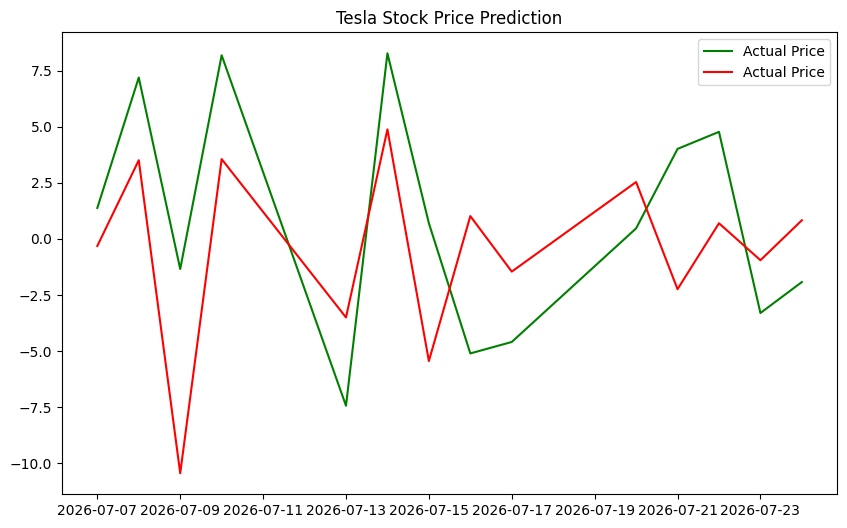

RMSE:  13.18


In [41]:
from statsmodels.tsa.api import VAR, VARMAX
import pandas as pd


#VAR
model=VAR(train_data)
result=model.fit(maxlags=7)
predictions=result.forecast(train_data.values[-result.k_ar:], steps=len(test_data))

predictions = pd.DataFrame(predictions, index=test_data.index, columns=test_data.columns)
plt.figure(figsize=(10,6))
plt.plot(test_data.index, test_data['NVDA_Close'], label='Actual Price', color='green')
plt.plot(test_data.index, predictions['TSLA_Close'], label='Actual Price', color='red')
plt.legend()
plt.title("Tesla Stock Price Prediction")
plt.show()

## rmse score
rmse=round(np.sqrt(mean_squared_error(test_data, predictions)),2)
print('RMSE: ',rmse)

# **Smoothing Methods**

Moving Average

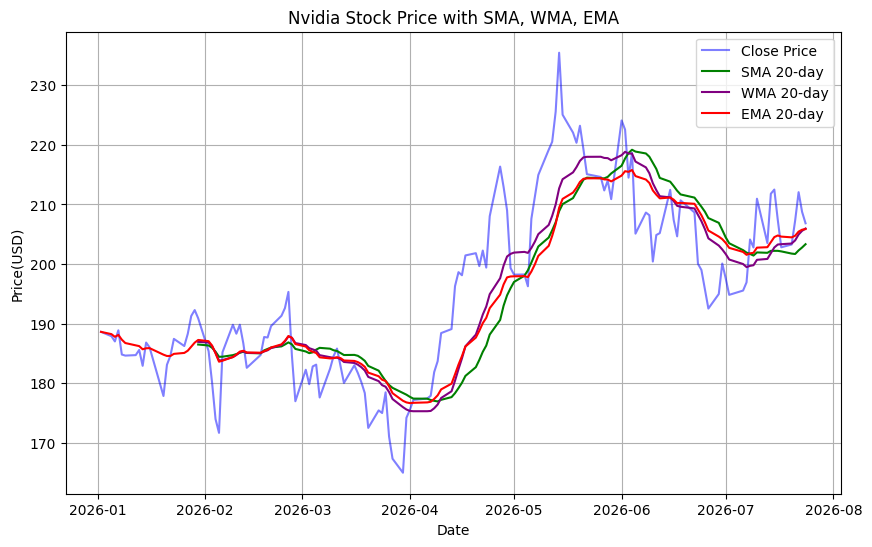

In [42]:
window_size=20
stock_data['SMA']=stock_data['Close'].rolling(window=window_size).mean()

## Calculate weighted Moving Average(WMA)
weights=np.arange(1,window_size + 1)
stock_data['WMA']=stock_data['Close'].rolling(window_size).apply(lambda prices: np.dot(prices,weights) / weights.sum(), raw=True)

## calculate Exponential Moving Average(EMA)
stock_data['EMA'] = stock_data['Close'].ewm(span=window_size).mean()

##plotting
plt.figure(figsize=(10,6))
plt.plot(stock_data['Close'],label='Close Price',color='blue', alpha=0.5)
plt.plot(stock_data['SMA'], label=f'SMA {window_size}-day', color='green')
plt.plot(stock_data['WMA'], label=f'WMA {window_size}-day', color='purple')
plt.plot(stock_data['EMA'], label=f'EMA {window_size}-day', color='red')

plt.title('Nvidia Stock Price with SMA, WMA, EMA')
plt.xlabel('Date')
plt.ylabel('Price(USD)')
plt.legend()
plt.grid()
plt.show()

EXPONENTIAL SMOOTHING

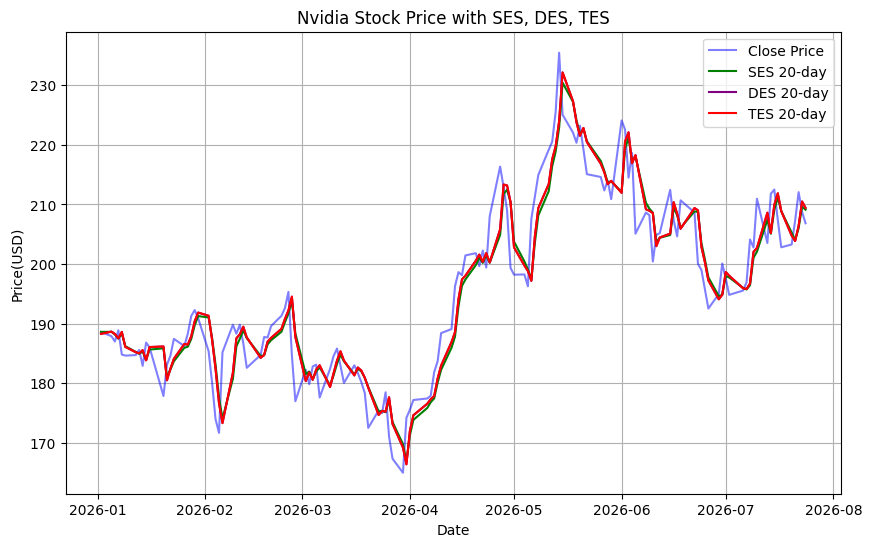

In [43]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing

close_prices=stock_data['Close']
ses_model=SimpleExpSmoothing(close_prices).fit(smoothing_level=0.6)
stock_data['SES'] = ses_model.fittedvalues

## Double exponential - Holt's linear model
des_model=ExponentialSmoothing(close_prices,trend='add').fit(smoothing_level=0.7)
stock_data['DES']=des_model.fittedvalues

## triple exponential - Holt's winters model
tes_model=ExponentialSmoothing(close_prices,trend='add',seasonal_periods=12).fit(smoothing_level=0.7)
stock_data['TES']=tes_model.fittedvalues

##plotting
plt.figure(figsize=(10,6))
plt.plot(stock_data['Close'],label='Close Price',color='blue', alpha=0.5)
plt.plot(stock_data['SES'], label=f'SES {window_size}-day', color='green')
plt.plot(stock_data['DES'], label=f'DES {window_size}-day', color='purple')
plt.plot(stock_data['TES'], label=f'TES {window_size}-day', color='red')

plt.title('Nvidia Stock Price with SES, DES, TES')
plt.xlabel('Date')
plt.ylabel('Price(USD)')
plt.legend()
plt.grid()
plt.show()